<a href="https://colab.research.google.com/github/gilIolgenblum/ProteinCrowding/blob/main/tutorials/05_parameter_sensitivity_and_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter Sensitivity and Interpretation

## Goal
In this tutorial, you will explore how the physical parameters in the Flory-Huggins thermodynamic framework govern protein stability.
We will visually inspect the effect of altering:
1. **Protein SASA** (Solvent Accessible Surface Area)
2. **Cosolute $\chi$** (Flory-Huggins non-ideal interaction)

## Setup
We import the package and `matplotlib.pyplot`.

In [1]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/ProteinCrowding.git
    # Change the working directory to the repository root
    os.chdir('/content/ProteinCrowding')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/ProteinCrowding/src')

Cloning into 'ProteinCrowding'...
remote: Enumerating objects: 464, done.
remote: Counting objects: 100% (464/464), done.
remote: Compressing objects: 100% (280/280), done.
remote: Total 464 (delta 238), reused 384 (delta 179), pack-reused 0 (from 0)
Receiving objects: 100% (464/464), 16.37 MiB | 11.22 MiB/s, done.
Resolving deltas: 100% (238/238), done.
Obtaining file:///content/ProteinCrowding
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fh_crowding (pyproject.toml) ... done
  Created wheel for fh_crowding: filename=fh_crowding-0.1.0-0.editable-py3-none-any.whl size=3165 sha256=91273a24bae139761cbf8717f6cffd2be1cfaacc5eae4c62931347e76fd79141
  Stored in directory: /tmp/pip-ephem-wheel-cache-1hj4fiol/wheels/8e/87/c6/59b0297bcdbde056eefb789604b557fd569845c8580cefb7a2
Successfully built fh_crowding


In [2]:
import fh_crowding
import matplotlib.pyplot as plt
import numpy as np

print(f"Module imported successfully: {fh_crowding.__name__}")

Module imported successfully: fh_crowding


## Effect of Protein SASA
The Solvent Accessible Surface Area (SASA) defines how much of the protein is exposed to the solvent and crowder.
Let's see what happens when we increase the SASA for the same cosolute.

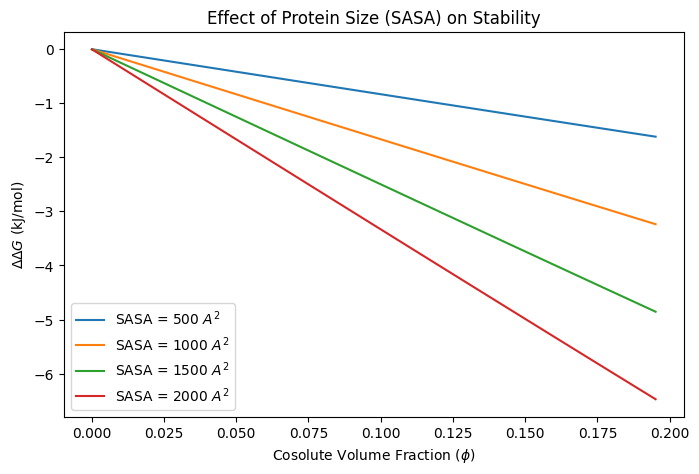

In [11]:
# Define a standard cosolute
cosolute = fh_crowding.Cosolute(nu=2.0, chi=0.5, chiTS=0.0)

sasa_values = [500, 1000, 1500, 2000]

fig, ax = plt.subplots(figsize=(8, 5))

for sasa in sasa_values:
    # Create the model with varying SASA
    protein = fh_crowding.Protein(SASA=sasa)
    model = fh_crowding.BinaryCrowdingModel(
        protein=protein,
        cosolute=cosolute,
        eps=0.0,
        epsTS=0.0,
        phiC_max=0.2,
        dphiC=0.005,
        T=298.15
    )

    # Solve
    model.solve_equil()

    # Plot
    ax.plot(model.phiC, model.ddA_kj, label=f"SASA = {sasa} $A^2$")

ax.set_xlabel(r"Cosolute Volume Fraction ($\phi$)")
ax.set_ylabel(r"$\Delta\Delta G$ (kJ/mol)")
ax.set_title("Effect of Protein Size (SASA) on Stability")
ax.legend()
plt.show()

### Interpretation of SASA
- The magnitude of the crowding effect scales linearly with the SASA of the protein.
- A larger protein (or a larger difference in SASA between the folded and unfolded states) will experience a much stronger thermodynamic push from the crowders.

## Effect of Flory-Huggins $\chi$
The $\chi$ parameter represents the non-ideal interaction between the cosolute and the solvent (water).
- $\chi < 0.5$: The cosolute prefers water (good solvent).
- $\chi > 0.5$: The cosolute avoids water (poor solvent), leading to stronger crowding effects on the protein.

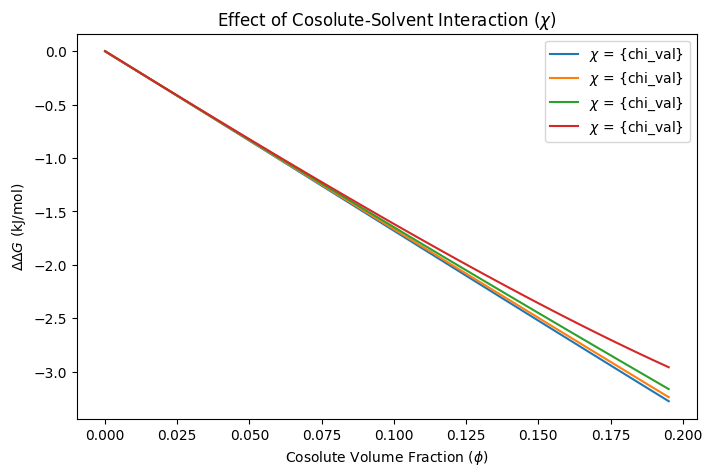

In [12]:
protein = fh_crowding.Protein(SASA=1000.0)

chi_values = [0.0, 0.5, 1.0, 1.5]

fig, ax = plt.subplots(figsize=(8, 5))

for chi_val in chi_values:
    # Create the model with varying chi
    cosolute = fh_crowding.Cosolute(nu=2.0, chi=chi_val, chiTS=0.0)

    model = fh_crowding.BinaryCrowdingModel(
        protein=protein,
        cosolute=cosolute,
        eps=0.0,
        epsTS=0.0,
        phiC_max=0.2,
        dphiC=0.005,
        T=298.15
    )

    # Solve
    model.solve_equil()

    # Plot
    ax.plot(model.phiC, model.ddA_kj, label=r"$\chi$ = {chi_val}")

ax.set_xlabel(r"Cosolute Volume Fraction ($\phi$)")
ax.set_ylabel(r"$\Delta\Delta G$ (kJ/mol)")
ax.set_title(r"Effect of Cosolute-Solvent Interaction ($\chi$)")
ax.legend()
plt.show()

### Interpretation of $\chi$
- As $\chi$ decrease, the cosolute effectively "squeezes" the protein more strongly (larger osmotic pressure), driving a more negative $\Delta\Delta G$ (stabilization of the compact folded state).

In the final tutorial, we'll quickly cover exporting these plots and datasets for manuscript preparation.

## Effect of Soft Interaction Energy ($\epsilon$) on $\Delta\Delta G$
The parameter $\epsilon$ represents the soft interaction energy between the cosolute and the protein surface. Positive values mean the cosolute is repelled from the surface (stabilizes the folded state), while negative values mean the cosolute is attracted to the surface (destabilizes the folded state).

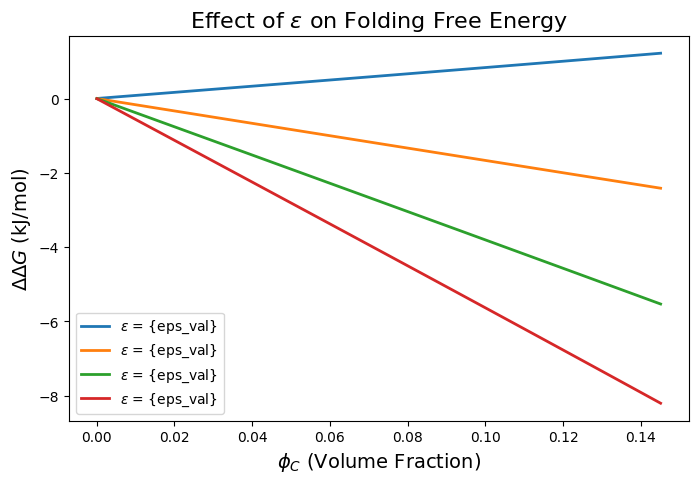

In [15]:
protein = fh_crowding.Protein(SASA=1000.0)
cosolute = fh_crowding.Cosolute(nu=2.0, chi=0.5, chiTS=0.0)
eps_values = [-0.1, 0.0, 0.1, 0.2]

fig, ax = plt.subplots(figsize=(8, 5))

for eps_val in eps_values:
    model = fh_crowding.BinaryCrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=eps_val, epsTS=0.0,
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    ax.plot(model.phiC, model.ddA_kj, lw=2, label=r'$\varepsilon$ = {eps_val}')

ax.set_xlabel(r'$\phi_C$ (Volume Fraction)', fontsize=14)
ax.set_ylabel(r'$\Delta\Delta G$ (kJ/mol)', fontsize=14)
ax.set_title(r'Effect of $\varepsilon$ on Folding Free Energy', fontsize=16)
ax.legend()
plt.show()

## Effect of Excluded Volume ($\nu$) on $\Delta\Delta H$ and $T\Delta\Delta S$
The parameter $\nu$ represents the excluded volume of the cosolute. Interestingly, changing the excluded volume affects the entropy ($T\Delta\Delta S$) but has absolutely no effect on the enthalpy ($\Delta\Delta H$).

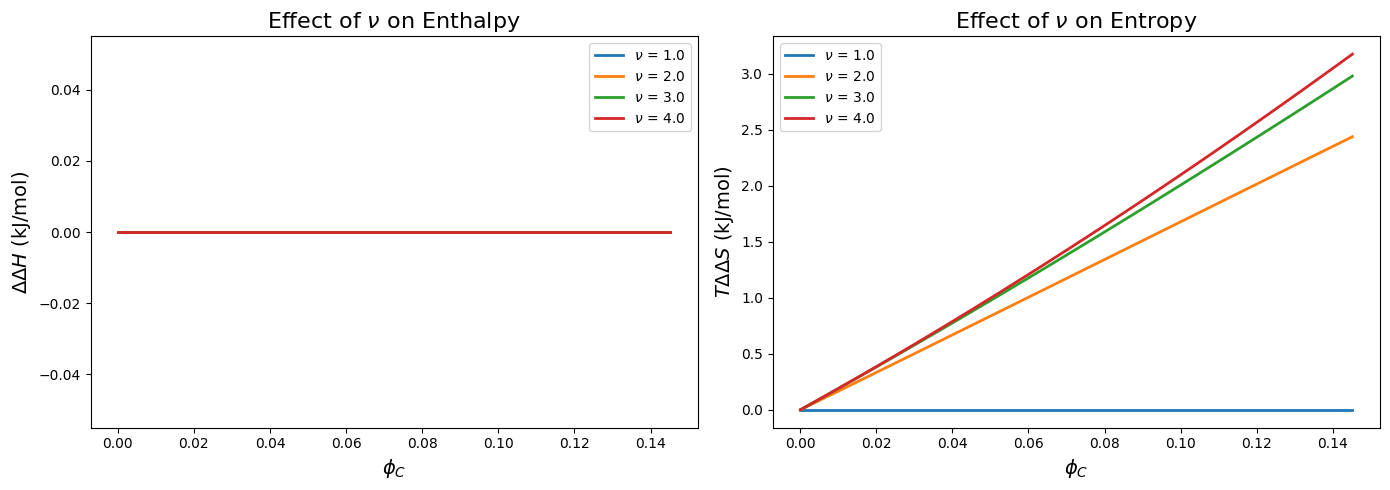

In [16]:
protein = fh_crowding.Protein(SASA=1000.0)
nu_values = [1.0, 2.0, 3.0, 4.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nu_val in nu_values:
    cosolute = fh_crowding.Cosolute(nu=nu_val, chi=0.0, chiTS=0.0)
    model = fh_crowding.BinaryCrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=0.0, epsTS=0.0,
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    axes[0].plot(model.phiC, model.ddE_kj, lw=2, label=rf'$\nu$ = {nu_val}')
    axes[1].plot(model.phiC, model.TddS_kj, lw=2, label=rf'$\nu$ = {nu_val}')

axes[0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Delta H$ (kJ/mol)', fontsize=14)
axes[0].set_title(r'Effect of $\nu$ on Enthalpy', fontsize=16)
axes[0].legend()

axes[1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1].set_ylabel(r'$T\Delta\Delta S$ (kJ/mol)', fontsize=14)
axes[1].set_title(r'Effect of $\nu$ on Entropy', fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of $\chi_{TS}$ on $\Delta\Delta H$ and $T\Delta\Delta S$
The parameter $\chi_{TS}$ represents the entropic component of the Flory-Huggins interaction parameter $\chi$. Modifying it alters the balance between enthalpy and entropy for the non-ideal mixing term.

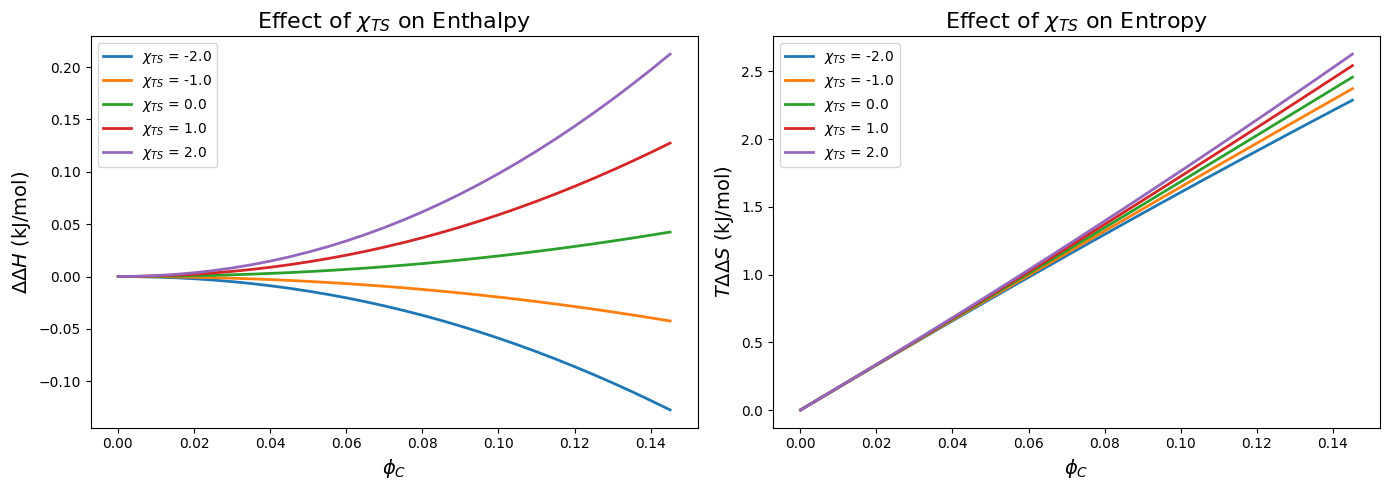

In [18]:
protein = fh_crowding.Protein(SASA=1000.0)
chiTS_values = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for chiTS_val in chiTS_values:
    # Keeping total chi constant, modifying chiTS
    cosolute = fh_crowding.Cosolute(nu=2.0, chi=0.5, chiTS=chiTS_val)
    model = fh_crowding.BinaryCrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=0.0, epsTS=0.0,
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    axes[0].plot(model.phiC, model.ddE_kj, lw=2, label=rf'$\chi_{{TS}}$ = {chiTS_val}')
    axes[1].plot(model.phiC, model.TddS_kj, lw=2, label=rf'$\chi_{{TS}}$ = {chiTS_val}')

axes[0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Delta H$ (kJ/mol)', fontsize=14)
axes[0].set_title(r'Effect of $\chi_{TS}$ on Enthalpy', fontsize=16)
axes[0].legend()

axes[1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1].set_ylabel(r'$T\Delta\Delta S$ (kJ/mol)', fontsize=14)
axes[1].set_title(r'Effect of $\chi_{TS}$ on Entropy', fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.show()

## Effect of Soft Interaction Entropy ($\epsilon_{TS}$) on $\Delta\Delta H$ and $T\Delta\Delta S$
The parameter $\epsilon_{TS}$ is the entropic component of the soft interaction $\epsilon$. Similar to $\chi_{TS}$, it splits the total free energy contribution of the soft interaction into enthalpic and entropic components.

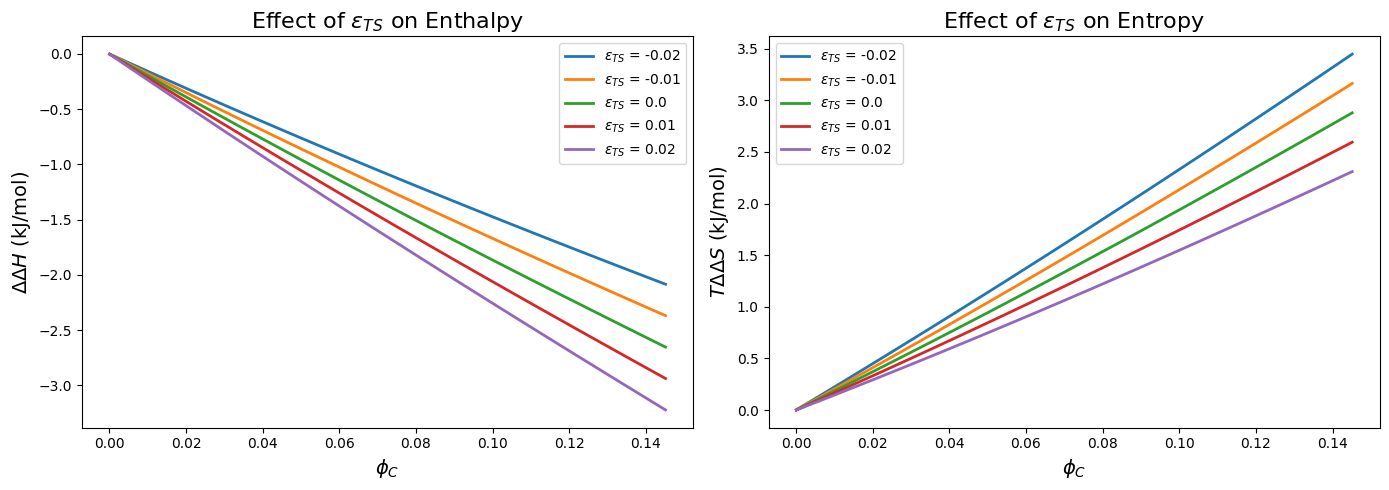

In [20]:
protein = fh_crowding.Protein(SASA=1000.0)
cosolute = fh_crowding.Cosolute(nu=2.0, chi=0.5, chiTS=0.0)
epsTS_values = [-0.02, -0.01, 0.0, 0.01, 0.02]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for epsTS_val in epsTS_values:
    model = fh_crowding.BinaryCrowdingModel(
        protein=protein, cosolute=cosolute,
        eps=0.1, epsTS=epsTS_val, # Keeping eps fixed, varying epsTS
        phiC_max=0.15, dphiC=0.005, T=298.15
    )
    model.solve_equil()
    axes[0].plot(model.phiC, model.ddE_kj, lw=2, label=rf'$\varepsilon_{{TS}}$ = {epsTS_val}')
    axes[1].plot(model.phiC, model.TddS_kj, lw=2, label=rf'$\varepsilon_{{TS}}$ = {epsTS_val}')

axes[0].set_xlabel(r'$\phi_C$', fontsize=14)
axes[0].set_ylabel(r'$\Delta\Delta H$ (kJ/mol)', fontsize=14)
axes[0].set_title(r'Effect of $\varepsilon_{TS}$ on Enthalpy', fontsize=16)
axes[0].legend()

axes[1].set_xlabel(r'$\phi_C$', fontsize=14)
axes[1].set_ylabel(r'$T\Delta\Delta S$ (kJ/mol)', fontsize=14)
axes[1].set_title(r'Effect of $\varepsilon_{TS}$ on Entropy', fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.show()